## Importing data:

In [190]:
import pandas as pd

train_path = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
test_path = '/kaggle/input/competitions/playground-series-s6e3/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape) 
display(train_df.head(3))
print("Test shape:", test_df.shape)
display(test_df.head(3))

Train shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


Test shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


In [191]:
target = 'Churn'

cat_cols = ['gender','Partner', 'Dependents', 'SeniorCitizen',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',] 

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [192]:
train_df[target] = train_df[target].map({'No': 0, 'Yes': 1})

## Feature Engineering:
We'll include **Digit Decomposition** from the most iteration and add **TargetEncoding** newly...

In [193]:
combined_df = pd.concat([train_df,test_df], axis=0, ignore_index=True)

#### Digit Decomposition:

In [194]:
import numpy as np

digit_cols = []

for col in num_cols:
    max_val = combined_df[col].abs().max()

    #conditional 1:
    if max_val == 0:
        digit_count = 1
    else:
      digit_count = int(np.log10(max_val)) + 1  

    for i in range(digit_count):
        new_col = f"{col}_digit_pos_{i+1}"

        combined_df[new_col] = (combined_df[col] // (10**i)) % 10
        combined_df[new_col] = combined_df[new_col].astype(int)

        digit_cols.append(new_col)

    #conditional 2:
    if combined_df[col].dtype == 'float64':
        max_dec_count = 2

        if (combined_df[col] % 1 != 0).any():
            for i in range(1, max_dec_count + 1):
                new_col = f"{col}_digit_dec_{i}"
                
                combined_df[new_col] = (combined_df[col] * (10**i)).round().astype(int) % 10
                
                digit_cols.append(new_col)

In [195]:
print('Newly created digit_cols are as follows: \n',digit_cols)

Newly created digit_cols are as follows: 
 ['tenure_digit_pos_1', 'tenure_digit_pos_2', 'MonthlyCharges_digit_pos_1', 'MonthlyCharges_digit_pos_2', 'MonthlyCharges_digit_pos_3', 'MonthlyCharges_digit_dec_1', 'MonthlyCharges_digit_dec_2', 'TotalCharges_digit_pos_1', 'TotalCharges_digit_pos_2', 'TotalCharges_digit_pos_3', 'TotalCharges_digit_pos_4', 'TotalCharges_digit_dec_1', 'TotalCharges_digit_dec_2']


In [196]:
train_df = combined_df.iloc[: len(train_df)].reset_index(drop=True)
test_df  = combined_df.iloc[len(train_df) :].reset_index(drop=True)

#### TargetEncoder:
We'll be using the custom column transformer we made during Heart-Disease-Prediction competition for target encoding

In [197]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols):
        self.cat_cols = cat_cols
        self.mean_maps = {}
        self.global_mean = None
        
    def fit(self, X, y):
        X = X.copy()
        self.global_mean = y.mean()

        for col in self.cat_cols:
            self.mean_maps[col] = y.groupby(X[col]).mean()
        return self

    def transform(self, X):
        X = X.copy()
        
        for col in self.cat_cols:
            X[col + "_TE"] = X[col].map(self.mean_maps[col])
            X[col + "_TE"] = X[col + "_TE"].fillna(self.global_mean) #handling unseen values
        return X

In [198]:
from sklearn.pipeline import Pipeline

TE = TargetEncoder(cat_cols=cat_cols) #TargetEncoder instance

train_TE = TE.fit_transform(train_df[cat_cols],train_df[target])
test_TE = TE.transform(test_df[cat_cols])

#dropping caat_cols from train_TE and test_TE
train_TE = train_TE.drop(cat_cols, axis=1)
test_TE = test_TE.drop(cat_cols, axis=1)

In [199]:
TE_cols = train_TE.columns.tolist()
print('Newly created TE_cols are as follows: \n', TE_cols)

Newly created TE_cols are as follows: 
 ['gender_TE', 'Partner_TE', 'Dependents_TE', 'SeniorCitizen_TE', 'PhoneService_TE', 'MultipleLines_TE', 'InternetService_TE', 'OnlineSecurity_TE', 'OnlineBackup_TE', 'DeviceProtection_TE', 'TechSupport_TE', 'StreamingTV_TE', 'StreamingMovies_TE', 'Contract_TE', 'PaperlessBilling_TE', 'PaymentMethod_TE']


## Feature Importance:

In [200]:
features = cat_cols + num_cols + TE_cols + digit_cols

In [201]:
X = pd.concat([train_df,train_TE], axis=1)
X_test = pd.concat([test_df,test_TE], axis=1)

In [202]:
for df in [X, X_test]:
    for col in cat_cols:
        df[col] = df[col].astype(str).astype('category')

In [203]:
#These hyperparameters were chosen by Optuna
best_xgb_params = {'n_estimators': 2500,
                   'learning_rate': 0.021343076630791043,
                   'max_depth': 6,
                   'min_child_weight': 7,
                   'gamma': 0.861751498622332, 
                   'subsample': 0.8551145690799331,
                   'colsample_bytree': 0.6623034984700539,
                   'reg_alpha': 0.019334069196449158,
                   'reg_lambda': 6.572714277172166}

In [204]:
from xgboost import XGBClassifier

model = XGBClassifier(
    **best_xgb_params,
    random_state= 42,
    eval_metric= "logloss",
    tree_method= "hist",   
    verbosity= 0,
    device= 'cuda',
    enable_categorical= True
)

model.fit(X[features],X[target])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6623034984700539, device='cuda',
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.861751498622332, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.021343076630791043,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=None,
              num_parallel_tree=None, ...)

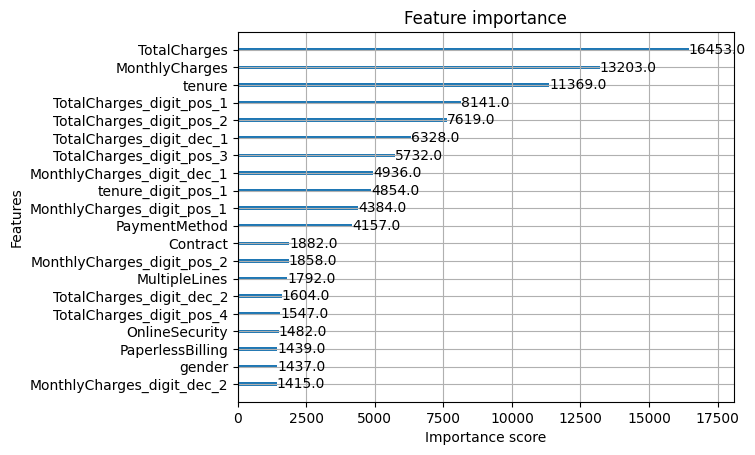

In [205]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=20)
plt.show()

In [212]:
y_pred = model.predict_proba(X_test[features])[:,1]

In [213]:
submission = pd.DataFrame({
    'id': test_df['id'],
    target: y_pred 
})

submission.to_csv('submission1.csv', index= False)